          MEMORY-OPTIMIZED ENSEMBLE DEEPFAKE DETECTION
          XGBoost + Random Forest + LightGBM
          Soft Voting | Hard Voting | Stacking
                              (Optimized for 12GB RAM)

⚙️  Memory-Optimized Configuration:
   Target per class: 800
   Mel bins: 96
   Sample rate: 16000 Hz

[STEP 1] Loading Dataset (Memory-Efficient)...
✓ Loaded 800 samples from Hugging Face

📊 Initial Dataset:
   Real (0): 100
   Fake (1): 700

[STEP 2] Data Augmentation (Memory-Efficient)...
   Real class: need 700 augmented samples
   Fake class: need 100 augmented samples
✓ Created augmentation plan for 800 samples

[STEP 3] Spectrogram Generation (Memory-Efficient)...
   Generating spectrograms for entire dataset...
      Generated 1600/1600
✓ Generated 1600 spectrograms
✓ Spectrogram shape: (1600, 96, 79, 3)

   Visualizing sample spectrograms...


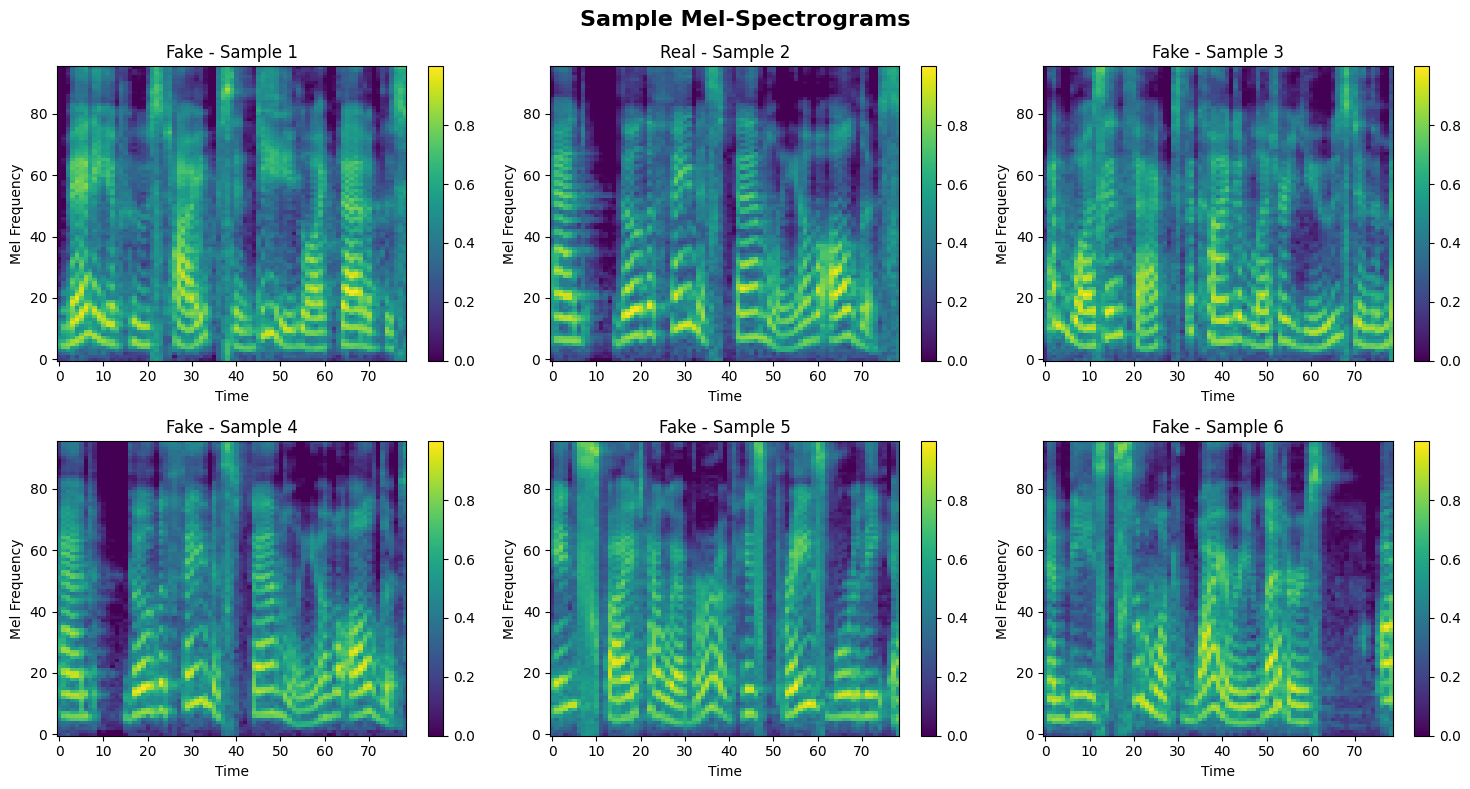


✓ Training set: 1280 samples
✓ Test set: 320 samples

[STEP 4] Building Compact CNN Feature Extractor...
   Building CNN feature extractor...
✓ CNN Extractor built! Parameters: 94,144

   Extracting features from spectrograms...

✓ Extracted features shape: (1280, 13824)

[STEP 5] Training Base Models...

   Training XGBoost...
   ✓ XGBoost trained!

   Training Random Forest...
   ✓ Random Forest trained!

   Training LightGBM...
   ✓ LightGBM trained!

[STEP 6] Training Ensemble Models...

   Creating Soft Voting Ensemble...
   ✓ Soft Voting Ensemble created!

   Creating Hard Voting Ensemble...
   ✓ Hard Voting Ensemble created!

   Creating Stacking Ensemble (Memory-Efficient)...
   Note: Using single job and 3-fold CV to avoid memory issues...
   ✓ Stacking Ensemble created!

[STEP 7] Comprehensive Evaluation...

   Evaluating Lightweight XGBoost...

   Evaluating Lightweight Random Forest...

   Evaluating Lightweight LightGBM...

   Evaluating Soft Voting Ensemble...

   Evalua

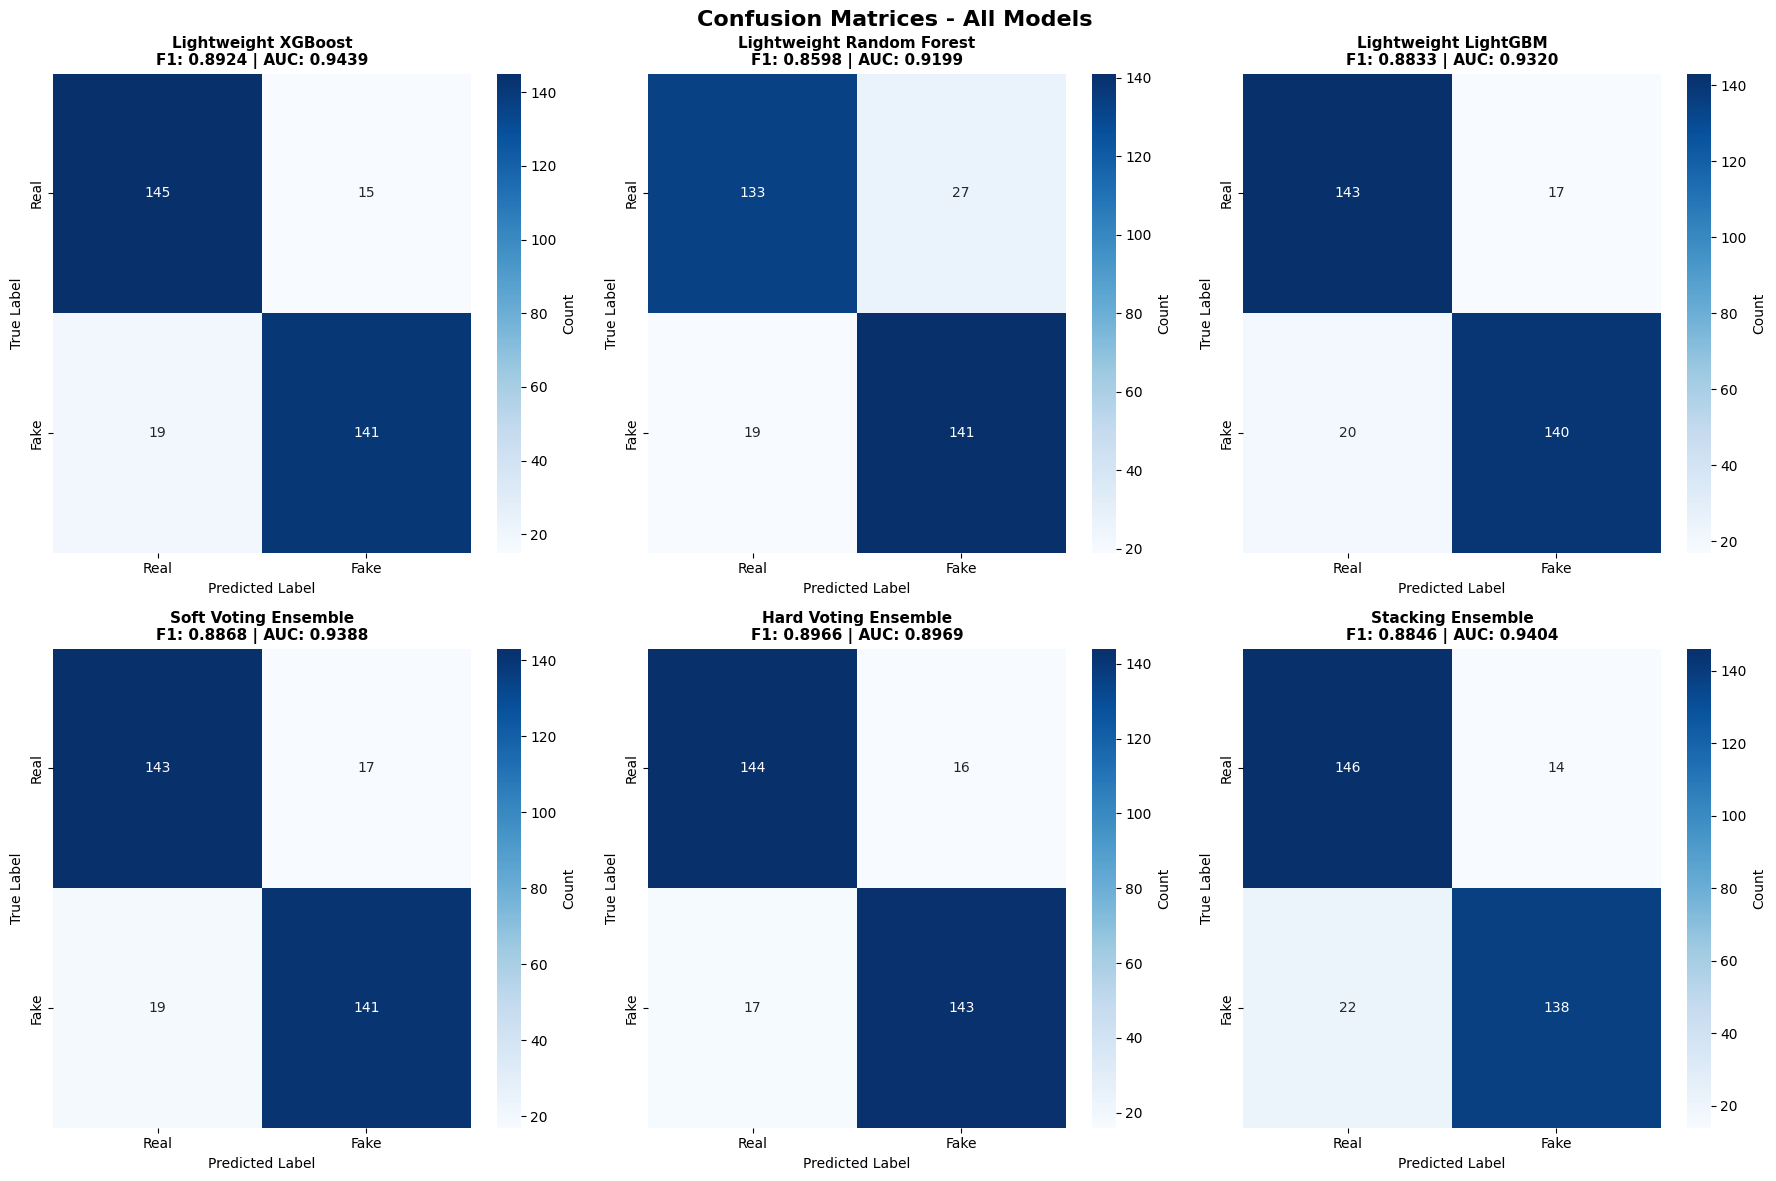

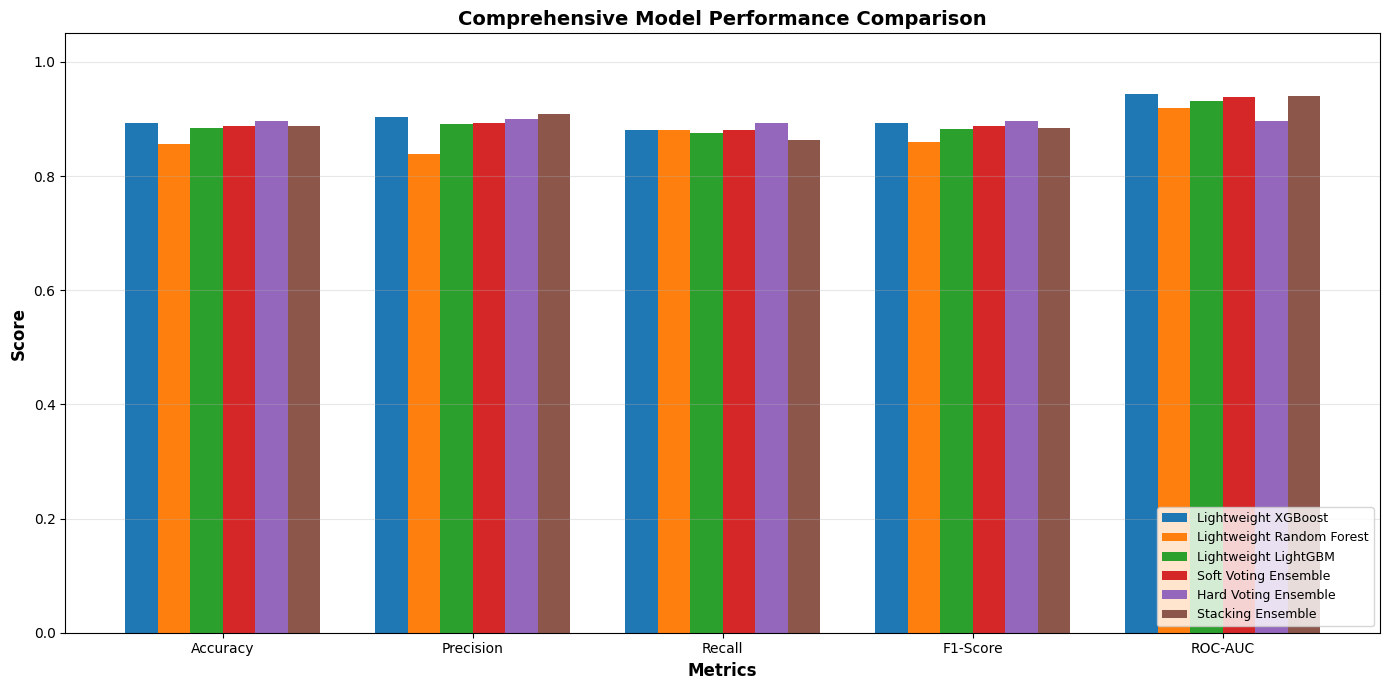

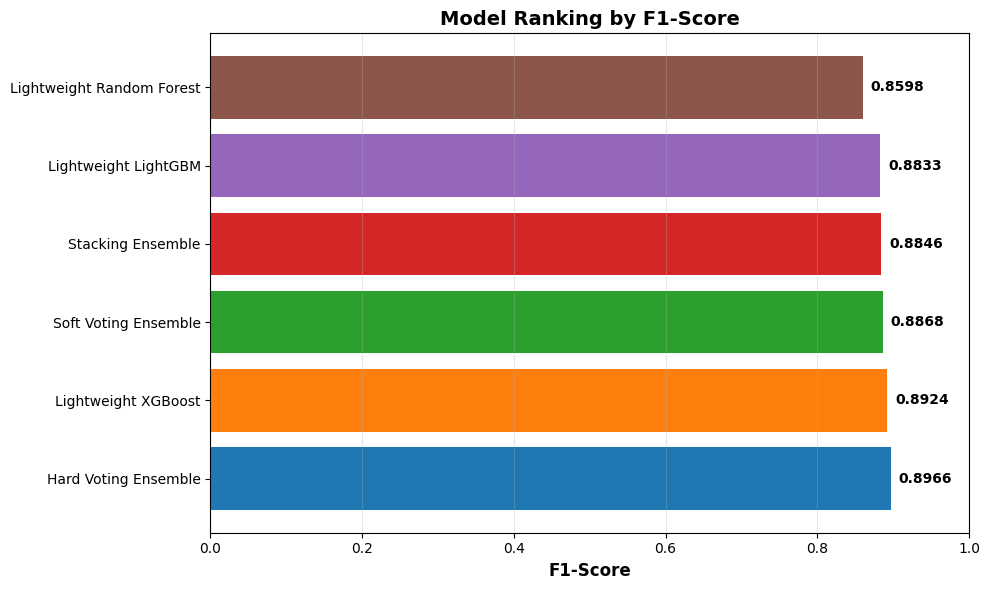


[STEP 8] Ensemble Techniques Comparison...

ENSEMBLE METHODS COMPARISON
               Model  Accuracy  F1-Score  ROC-AUC
Soft Voting Ensemble  0.887500  0.886792 0.938828
Hard Voting Ensemble  0.896875  0.896552 0.896875
   Stacking Ensemble  0.887500  0.884615 0.940352

📊 Ensemble Method Explanations:
   • Soft Voting: Averages predicted probabilities from all models
   • Hard Voting: Takes majority vote of class predictions
   • Stacking: Uses meta-learner (Logistic Regression) on base model predictions

[STEP 9] Saving Models...
✓ Saved: lightweight_xgboost.pkl
✓ Saved: lightweight_random_forest.pkl
✓ Saved: lightweight_lightgbm.pkl
✓ Saved: soft_voting_ensemble.pkl
✓ Saved: hard_voting_ensemble.pkl
✓ Saved: stacking_ensemble.pkl
✓ Saved: cnn_feature_extractor.keras
✓ Saved: config.pkl
✓ Saved: ensemble_results.csv

PIPELINE COMPLETE - COMPREHENSIVE ENSEMBLE WITH SOFT/HARD VOTING & STACKING

🏆 Best Model: Hard Voting Ensemble
   F1-Score: 0.8966
   Accuracy: 0.8969
   ROC-AUC: 0.8

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import wavfile
from scipy import signal
from scipy.fft import fft
import io
import random
import warnings
import pickle
import os
import gc
warnings.filterwarnings('ignore')

# Audio Processing
import librosa
import librosa.display

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              cohen_kappa_score, classification_report)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning (only for feature extraction)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                      BatchNormalization, Dropout)
from tensorflow.keras import backend as K

# Set memory growth for GPU (if available)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

print("=" * 100)
print(" " * 10 + "MEMORY-OPTIMIZED ENSEMBLE DEEPFAKE DETECTION")
print(" " * 10 + "XGBoost + Random Forest + LightGBM")
print(" " * 10 + "Soft Voting | Hard Voting | Stacking")
print(" " * 30 + "(Optimized for 12GB RAM)")
print("=" * 100)

# ============================================================================
# MEMORY-EFFICIENT CONFIGURATION
# ============================================================================
CONFIG = {
    'TARGET_PER_CLASS': 800,
    'N_MELS': 96,
    'TARGET_SR': 16000,
    'TARGET_DURATION': 2.5,
    'N_FFT': 1024,
    'HOP_LENGTH': 512,
}

print(f"\n⚙️  Memory-Optimized Configuration:")
print(f"   Target per class: {CONFIG['TARGET_PER_CLASS']}")
print(f"   Mel bins: {CONFIG['N_MELS']}")
print(f"   Sample rate: {CONFIG['TARGET_SR']} Hz")

# ============================================================================
# STEP 1: DATA LOADING
# ============================================================================
print("\n[STEP 1] Loading Dataset (Memory-Efficient)...")

try:
    df = pd.read_parquet("hf://datasets/ajaykarthick/wavefake-audio/data/partition0-00000-of-00001.parquet")
    print(f"✓ Loaded {len(df)} samples from Hugging Face")
    if len(df) > 2000:
        df = df.sample(n=2000, random_state=42).reset_index(drop=True)
        print(f"✓ Sampled to {len(df)} for memory efficiency")
except Exception as e:
    print(f"⚠ Could not load dataset: {e}")
    print("✓ Creating mock dataset...")

    def create_mock_audio_bytes(duration_seconds=2.5, sample_rate=16000):
        num_samples = int(duration_seconds * sample_rate)
        t = np.linspace(0, duration_seconds, num_samples)
        freq = np.random.uniform(100, 400)
        audio_data = np.sin(2 * np.pi * freq * t)
        audio_data += 0.5 * np.sin(2 * np.pi * freq * 2 * t)
        audio_data += 0.3 * np.random.normal(0, 0.1, num_samples)
        audio_data = (audio_data * 32767 / np.max(np.abs(audio_data))).astype(np.int16)
        buffer = io.BytesIO()
        wavfile.write(buffer, rate=sample_rate, data=audio_data)
        return {'bytes': buffer.getvalue()}

    unique_labels = ['R', 'WF1', 'WF2', 'WF3', 'WF4']
    N_SAMPLES = 500
    data = {
        'audio_id': [f'sample_{label}_{i}' for label in unique_labels for i in range(N_SAMPLES // 5)],
        'real_or_fake': [label for label in unique_labels for _ in range(N_SAMPLES // 5)],
    }
    df = pd.DataFrame(data)
    df['audio'] = df.apply(lambda row: create_mock_audio_bytes(), axis=1)
    print(f"✓ Created {len(df)} mock samples")

# Convert to binary labels
df['label'] = df['real_or_fake'].apply(lambda x: 0 if x == 'R' else 1)
print(f"\n📊 Initial Dataset:")
print(f"   Real (0): {(df['label'] == 0).sum()}")
print(f"   Fake (1): {(df['label'] == 1).sum()}")

# ============================================================================
# STEP 2: AUGMENTATION (MEMORY-EFFICIENT)
# ============================================================================
print("\n[STEP 2] Data Augmentation (Memory-Efficient)...")

def get_audio_data(audio_bytes_dict, target_sr=None):
    """Extract and resample audio"""
    if target_sr is None:
        target_sr = CONFIG['TARGET_SR']
    try:
        buffer = io.BytesIO(audio_bytes_dict['bytes'])
        sr, data = wavfile.read(buffer)
        if data.ndim > 1:
            data = data[:, 0]
        data = data.astype(np.float32)
        if np.max(np.abs(data)) > 0:
            data = data / np.max(np.abs(data))
        # Resample
        if sr != target_sr:
            duration = len(data) / sr
            new_length = int(duration * target_sr)
            data = np.interp(
                np.linspace(0, len(data)-1, new_length),
                np.arange(len(data)),
                data
            )
        return data, target_sr
    except:
        return np.array([]), 0

def augment_audio_advanced(data, sr, aug_type='noise'):
    """Advanced audio augmentation"""
    data = data.astype(np.float32)

    if aug_type == 'time_stretch':
        rate = np.random.uniform(0.9, 1.1)
        new_length = int(len(data) / rate)
        indices = np.linspace(0, len(data)-1, new_length)
        return np.interp(indices, np.arange(len(data)), data)
    elif aug_type == 'pitch_shift':
        n_steps = np.random.uniform(-2, 2)
        rate = 2 ** (n_steps / 12)
        new_length = int(len(data) * rate)
        indices = np.linspace(0, len(data)-1, new_length)
        return np.interp(indices, np.arange(len(data)), data)
    elif aug_type == 'noise':
        noise = np.random.normal(0, 0.005, len(data))
        return data + noise
    elif aug_type == 'shift':
        shift = np.random.randint(-len(data)//8, len(data)//8)
        return np.roll(data, shift)
    elif aug_type == 'volume':
        factor = np.random.uniform(0.7, 1.3)
        return data * factor
    return data

TARGET_PER_CLASS = CONFIG['TARGET_PER_CLASS']
augmentation_types = ['time_stretch', 'pitch_shift', 'noise', 'shift', 'volume']

# Store augmentation plan
augmentation_plan = []

for label_val in [0, 1]:
    current_count = (df['label'] == label_val).sum()
    needed = TARGET_PER_CLASS - current_count

    label_name = "Real" if label_val == 0 else "Fake"
    print(f"   {label_name} class: need {needed} augmented samples")

    if needed > 0:
        class_indices = df[df['label'] == label_val].index.tolist()
        for _ in range(needed):
            idx = np.random.choice(class_indices)
            aug_type = np.random.choice(augmentation_types)
            augmentation_plan.append((idx, aug_type, label_val))

print(f"✓ Created augmentation plan for {len(augmentation_plan)} samples")

# ============================================================================
# STEP 3: SPECTROGRAM GENERATION
# ============================================================================
print("\n[STEP 3] Spectrogram Generation (Memory-Efficient)...")

def create_spectrogram(audio_data, sr=None, n_mels=None):
    """Create mel-spectrogram"""
    if sr is None:
        sr = CONFIG['TARGET_SR']
    if n_mels is None:
        n_mels = CONFIG['N_MELS']

    target_length = int(CONFIG['TARGET_DURATION'] * sr)

    # Ensure proper length
    if len(audio_data) < target_length:
        audio_data = np.pad(audio_data, (0, target_length - len(audio_data)))
    else:
        audio_data = audio_data[:target_length]

    # Mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio_data, sr=sr, n_mels=n_mels,
        n_fft=CONFIG['N_FFT'], hop_length=CONFIG['HOP_LENGTH']
    )
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Normalize
    mel_spec_norm = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-8)
    mel_spec_norm = np.clip(mel_spec_norm, -3, 3)
    mel_spec_norm = (mel_spec_norm - mel_spec_norm.min()) / (mel_spec_norm.max() - mel_spec_norm.min() + 1e-8)

    # Add channel dimension
    spec_3channel = np.stack([mel_spec_norm, mel_spec_norm, mel_spec_norm], axis=-1)

    return spec_3channel

# Generate spectrograms
print("   Generating spectrograms for entire dataset...")
n_samples_to_generate = min(len(df) + len(augmentation_plan), 1600)
spectrograms = []
labels = []

for i in range(n_samples_to_generate):
    if i < len(df):
        audio_bytes = df.iloc[i]['audio']
        label = df.iloc[i]['label']
        audio_data, sr = get_audio_data(audio_bytes)
    else:
        aug_idx = i - len(df)
        if aug_idx < len(augmentation_plan):
            orig_idx, aug_type, label = augmentation_plan[aug_idx]
            audio_bytes = df.iloc[orig_idx]['audio']
            audio_data, sr = get_audio_data(audio_bytes)
            audio_data = augment_audio_advanced(audio_data, sr, aug_type)
        else:
            continue

    if len(audio_data) > 0:
        spec = create_spectrogram(audio_data, sr)
        spectrograms.append(spec)
        labels.append(label)

    if (i + 1) % 100 == 0:
        print(f"      Generated {i + 1}/{n_samples_to_generate}", end='\r')
        gc.collect()

print(f"\n✓ Generated {len(spectrograms)} spectrograms")
X_spectrograms = np.array(spectrograms)
y_labels = np.array(labels)

print(f"✓ Spectrogram shape: {X_spectrograms.shape}")

del spectrograms
gc.collect()

# Visualize sample spectrograms
print("\n   Visualizing sample spectrograms...")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i in range(6):
    idx = np.random.choice(len(X_spectrograms))
    ax = axes[i // 3, i % 3]
    label = "Real" if y_labels[idx] == 0 else "Fake"

    im = ax.imshow(X_spectrograms[idx, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(f'{label} - Sample {i+1}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Mel Frequency')
    plt.colorbar(im, ax=ax)

plt.suptitle('Sample Mel-Spectrograms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_spectrograms, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"\n✓ Training set: {X_train.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")

gc.collect()

# ============================================================================
# STEP 4: FEATURE EXTRACTION WITH COMPACT CNN
# ============================================================================
print("\n[STEP 4] Building Compact CNN Feature Extractor...")

def build_compact_cnn_extractor(input_shape):
    """Compact CNN feature extractor"""
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    model = Model(inputs=inputs, outputs=x, name='Compact_CNN_Extractor')
    return model

print("   Building CNN feature extractor...")
cnn_extractor = build_compact_cnn_extractor(X_train.shape[1:])
print(f"✓ CNN Extractor built! Parameters: {cnn_extractor.count_params():,}")

# Extract features in batches
print("\n   Extracting features from spectrograms...")
batch_size_extract = 32
X_train_features_list = []
X_test_features_list = []

# Extract train features
for i in range(0, len(X_train), batch_size_extract):
    batch = X_train[i:i+batch_size_extract]
    features = cnn_extractor.predict(batch, verbose=0)
    X_train_features_list.append(features)
    if (i + batch_size_extract) % 100 == 0:
        print(f"      Train: {i + batch_size_extract}/{len(X_train)}", end='\r')
        gc.collect()

# Extract test features
for i in range(0, len(X_test), batch_size_extract):
    batch = X_test[i:i+batch_size_extract]
    features = cnn_extractor.predict(batch, verbose=0)
    X_test_features_list.append(features)
    gc.collect()

X_train_features = np.concatenate(X_train_features_list, axis=0)
X_test_features = np.concatenate(X_test_features_list, axis=0)

del X_train_features_list, X_test_features_list
gc.collect()

# Flatten features
X_train_flat = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_flat = X_test_features.reshape(X_test_features.shape[0], -1)

print(f"\n✓ Extracted features shape: {X_train_flat.shape}")

del X_train_features, X_test_features
gc.collect()

# ============================================================================
# STEP 5: TRAIN BASE MODELS
# ============================================================================
print("\n[STEP 5] Training Base Models...")

print("\n   Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_flat, y_train)
print(f"   ✓ XGBoost trained!")

print("\n   Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_flat, y_train)
print(f"   ✓ Random Forest trained!")

print("\n   Training LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train_flat, y_train)
print(f"   ✓ LightGBM trained!")

# ============================================================================
# STEP 6: TRAIN ENSEMBLE MODELS
# ============================================================================
print("\n[STEP 6] Training Ensemble Models...")

# Soft Voting Ensemble
print("\n   Creating Soft Voting Ensemble...")
soft_voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('lgbm', lgbm_model)
    ],
    voting='soft',
    n_jobs=-1
)
soft_voting_clf.fit(X_train_flat, y_train)
print(f"   ✓ Soft Voting Ensemble created!")

# Hard Voting Ensemble
print("\n   Creating Hard Voting Ensemble...")
hard_voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('lgbm', lgbm_model)
    ],
    voting='hard',
    n_jobs=-1
)
hard_voting_clf.fit(X_train_flat, y_train)
print(f"   ✓ Hard Voting Ensemble created!")

# Stacking Ensemble (Memory-Efficient)
print("\n   Creating Stacking Ensemble (Memory-Efficient)...")
print("   Note: Using single job and 3-fold CV to avoid memory issues...")

# Clear memory before stacking
gc.collect()

stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('lgbm', lgbm_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,  # Reduced from 5 to save memory
    n_jobs=1,  # Single job to avoid memory explosion
    passthrough=False  # Don't pass original features to save memory
)

try:
    stacking_clf.fit(X_train_flat, y_train)
    print(f"   ✓ Stacking Ensemble created!")
    stacking_success = True
except Exception as e:
    print(f"   ⚠ Stacking failed due to memory constraints: {str(e)[:100]}")
    print(f"   ✓ Continuing with Soft and Hard Voting ensembles only")
    stacking_success = False
    stacking_clf = None

gc.collect()

# ============================================================================
# STEP 7: EVALUATION
# ============================================================================
print("\n[STEP 7] Comprehensive Evaluation...")

results = []

# Evaluate all models
models_to_evaluate = [
    ('Lightweight XGBoost', xgb_model),
    ('Lightweight Random Forest', rf_model),
    ('Lightweight LightGBM', lgbm_model),
    ('Soft Voting Ensemble', soft_voting_clf),
    ('Hard Voting Ensemble', hard_voting_clf),
]

# Only add stacking if it was successfully created
if stacking_success and stacking_clf is not None:
    models_to_evaluate.append(('Stacking Ensemble', stacking_clf))

for name, model in models_to_evaluate:
    print(f"\n   Evaluating {name}...")

    y_pred = model.predict(X_test_flat)

    # Get probabilities (handle hard voting which doesn't have predict_proba)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_flat)[:, 1]
    else:
        y_proba = y_pred.astype(float)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if len(np.unique(y_proba)) > 1 else 0.0,
        'Kappa': cohen_kappa_score(y_test, y_pred),
        'CM': confusion_matrix(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print("\n" + "=" * 110)
print("EVALUATION RESULTS - COMPREHENSIVE ENSEMBLE COMPARISON")
print("=" * 110)

display_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Kappa']].copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Kappa']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")

print(display_df.to_string(index=False))
print("=" * 110)

# Confusion matrices
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, result in enumerate(results):
    cm = result['CM']
    ax = axes[idx]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
                cbar_kws={'label': 'Count'})
    ax.set_title(f"{result['Model']}\nF1: {result['F1-Score']:.4f} | AUC: {result['ROC-AUC']:.4f}",
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Hide extra subplots if any
for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Performance comparison chart
fig, ax = plt.subplots(figsize=(14, 7))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.13

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, result in enumerate(results):
    values = [result[metric] for metric in metrics]
    ax.bar(x + i*width, values, width, label=result['Model'], color=colors[i])

ax.set_xlabel('Metrics', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Comprehensive Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Model ranking by F1-Score
fig, ax = plt.subplots(figsize=(10, 6))
sorted_results = sorted(results, key=lambda x: x['F1-Score'], reverse=True)
models = [r['Model'] for r in sorted_results]
f1_scores = [r['F1-Score'] for r in sorted_results]

bars = ax.barh(models, f1_scores, color=colors[:len(models)])
ax.set_xlabel('F1-Score', fontweight='bold', fontsize=12)
ax.set_title('Model Ranking by F1-Score', fontweight='bold', fontsize=14)
ax.set_xlim([0, 1])

# Add value labels
for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    ax.text(score + 0.01, i, f'{score:.4f}', va='center', fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 8: ENSEMBLE COMPARISON TABLE
# ============================================================================
print("\n[STEP 8] Ensemble Techniques Comparison...")

ensemble_results = results_df[results_df['Model'].str.contains('Ensemble|Stacking')]
print("\n" + "=" * 90)
print("ENSEMBLE METHODS COMPARISON")
print("=" * 90)
print(ensemble_results[['Model', 'Accuracy', 'F1-Score', 'ROC-AUC']].to_string(index=False))
print("=" * 90)

print("\n📊 Ensemble Method Explanations:")
print("   • Soft Voting: Averages predicted probabilities from all models")
print("   • Hard Voting: Takes majority vote of class predictions")
if stacking_success:
    print("   • Stacking: Uses meta-learner (Logistic Regression) on base model predictions")
else:
    print("   • Stacking: Not available (requires more memory)")

# ============================================================================
# STEP 9: SAVE MODELS
# ============================================================================
print("\n[STEP 9] Saving Models...")

with open('lightweight_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("✓ Saved: lightweight_xgboost.pkl")

with open('lightweight_random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✓ Saved: lightweight_random_forest.pkl")

with open('lightweight_lightgbm.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
print("✓ Saved: lightweight_lightgbm.pkl")

with open('soft_voting_ensemble.pkl', 'wb') as f:
    pickle.dump(soft_voting_clf, f)
print("✓ Saved: soft_voting_ensemble.pkl")

with open('hard_voting_ensemble.pkl', 'wb') as f:
    pickle.dump(hard_voting_clf, f)
print("✓ Saved: hard_voting_ensemble.pkl")

if stacking_success and stacking_clf is not None:
    with open('stacking_ensemble.pkl', 'wb') as f:
        pickle.dump(stacking_clf, f)
    print("✓ Saved: stacking_ensemble.pkl")
else:
    print("⚠ Stacking ensemble not saved (not created due to memory constraints)")

cnn_extractor.save('cnn_feature_extractor.keras')
print("✓ Saved: cnn_feature_extractor.keras")

with open('config.pkl', 'wb') as f:
    pickle.dump(CONFIG, f)
print("✓ Saved: config.pkl")

results_df.to_csv('ensemble_results.csv', index=False)
print("✓ Saved: ensemble_results.csv")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 110)
print("PIPELINE COMPLETE - COMPREHENSIVE ENSEMBLE WITH SOFT/HARD VOTING & STACKING")
print("=" * 110)

best = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\n🏆 Best Model: {best['Model']}")
print(f"   F1-Score: {best['F1-Score']:.4f}")
print(f"   Accuracy: {best['Accuracy']:.4f}")
print(f"   ROC-AUC: {best['ROC-AUC']:.4f}")
print(f"   Precision: {best['Precision']:.4f}")
print(f"   Recall: {best['Recall']:.4f}")

print(f"\n📦 Base Models:")
print(f"   ✓ XGBoost: 150 trees, max_depth=6")
print(f"   ✓ Random Forest: 150 trees, max_depth=15")
print(f"   ✓ LightGBM: 150 trees, max_depth=6")

print(f"\n🔗 Ensemble Methods:")
print(f"   ✓ Soft Voting: Probability averaging")
print(f"   ✓ Hard Voting: Majority class voting")
if stacking_success:
    print(f"   ✓ Stacking: Logistic Regression meta-learner with 3-fold CV")
else:
    print(f"   ✗ Stacking: Skipped due to memory constraints")

print(f"\n🎯 Total Models Evaluated: {len(results_df)}")
print(f"   - Base Models: 3")
print(f"   - Ensemble Models: {len(results_df) - 3}")

print(f"\n💾 Memory Optimizations:")
print(f"   ✓ CNN feature extractor: {cnn_extractor.count_params():,} params")
print(f"   ✓ Feature dimension: {X_train_flat.shape[1]}")
print(f"   ✓ Batch processing with GC")
print(f"   ✓ No heavy deep learning training")

print("\n" + "=" * 110)